Датасэт ToyotaCorolla из https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars.

In [25]:
import pandas as pd
import time
from category_encoders import TargetEncoder
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb
import plotly.express as px
from sklearn.preprocessing import RobustScaler , PolynomialFeatures, StandardScaler , MinMaxScaler
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
df = pd.read_csv('ToyotaCorolla.csv')
df.shape

(1436, 39)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [27]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [28]:
bins = []
for col in df.select_dtypes('number').columns:
    
    if df[col].min() ==0 and df[col].max() == 1:
        bins.append(col)
    else: 
        print(f"{col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

Id: [1.00, 1442.00]
Price: [4350.00, 32500.00]
Age_08_04: [1.00, 80.00]
Mfg_Month: [1.00, 12.00]
Mfg_Year: [1998.00, 2004.00]
KM: [1.00, 243000.00]
HP: [69.00, 192.00]
CC: [1300.00, 16000.00]
Doors: [2.00, 5.00]
Cylinders: [4.00, 4.00]
Gears: [3.00, 6.00]
Quarterly_Tax: [19.00, 283.00]
Weight: [1000.00, 1615.00]
Guarantee_Period: [3.00, 36.00]


In [29]:
df_for_corr = df.select_dtypes('number').drop(columns=bins).drop(columns=['Cylinders', 'Id'])

<Axes: >

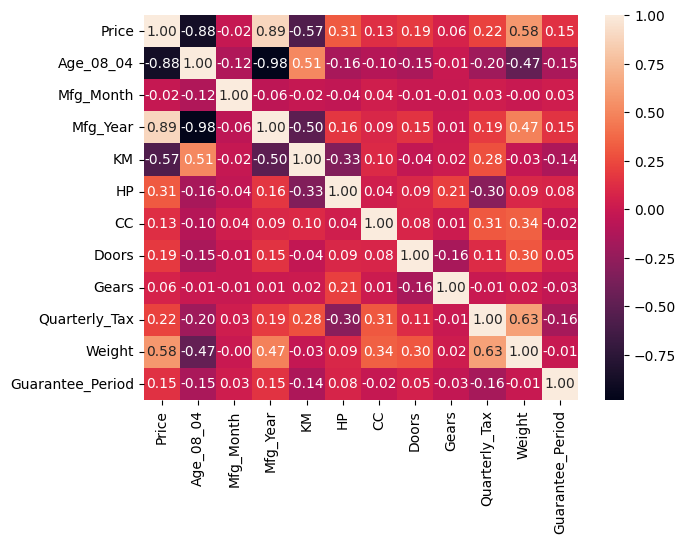

In [30]:
plt.figure(figsize=(7, 5))
sb.heatmap(df_for_corr.corr(),annot=True,fmt=".2f")

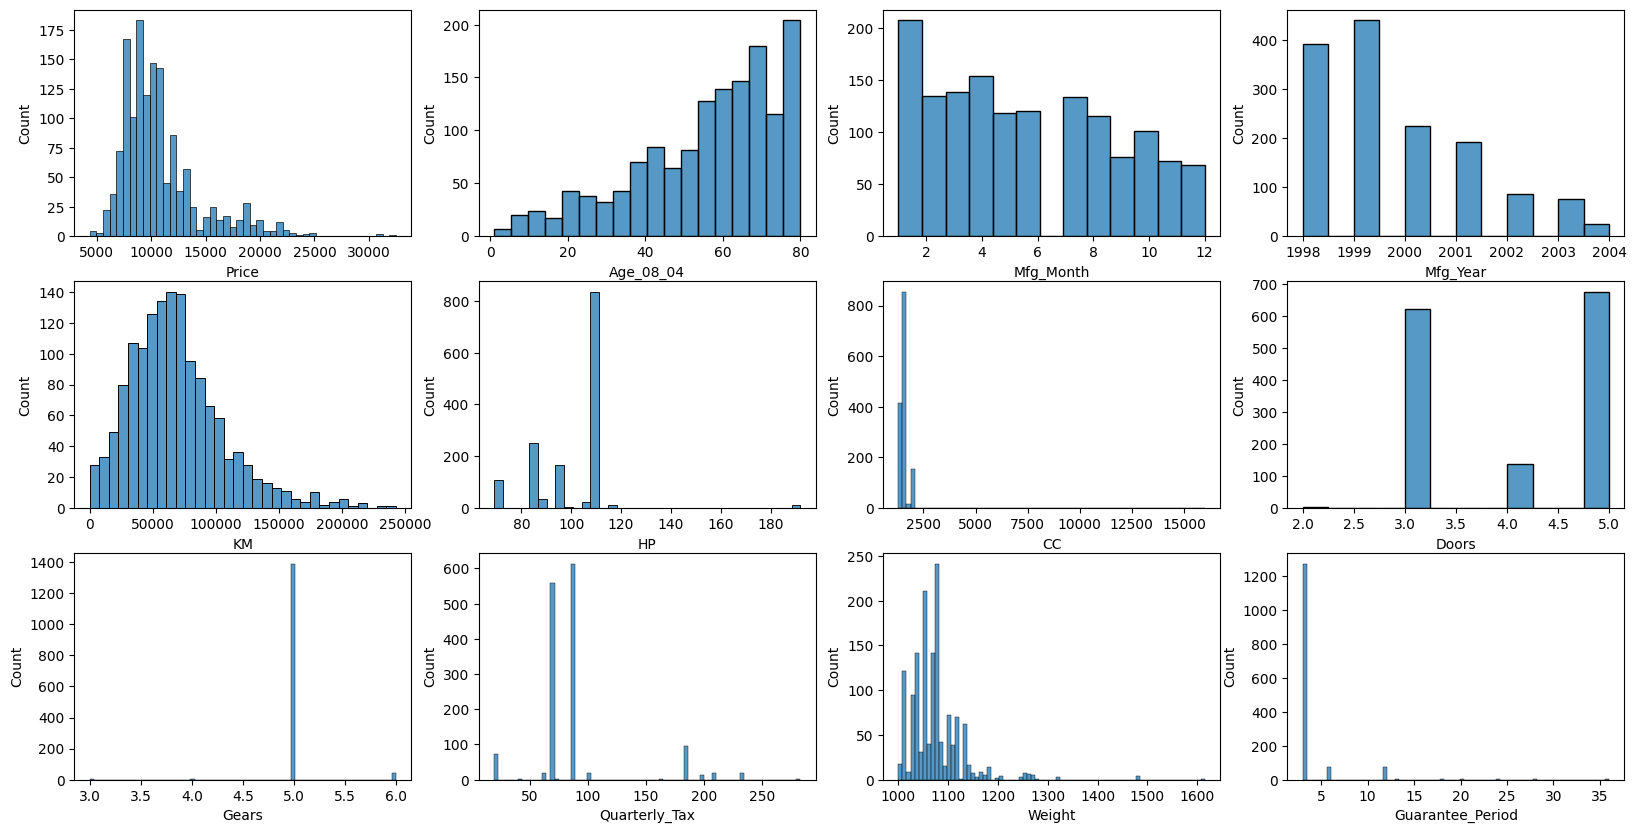

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))

for i, el in enumerate(df_for_corr.columns.array):
    sb.histplot(data=df_for_corr, x=el, ax=axes[i//4, i%4])

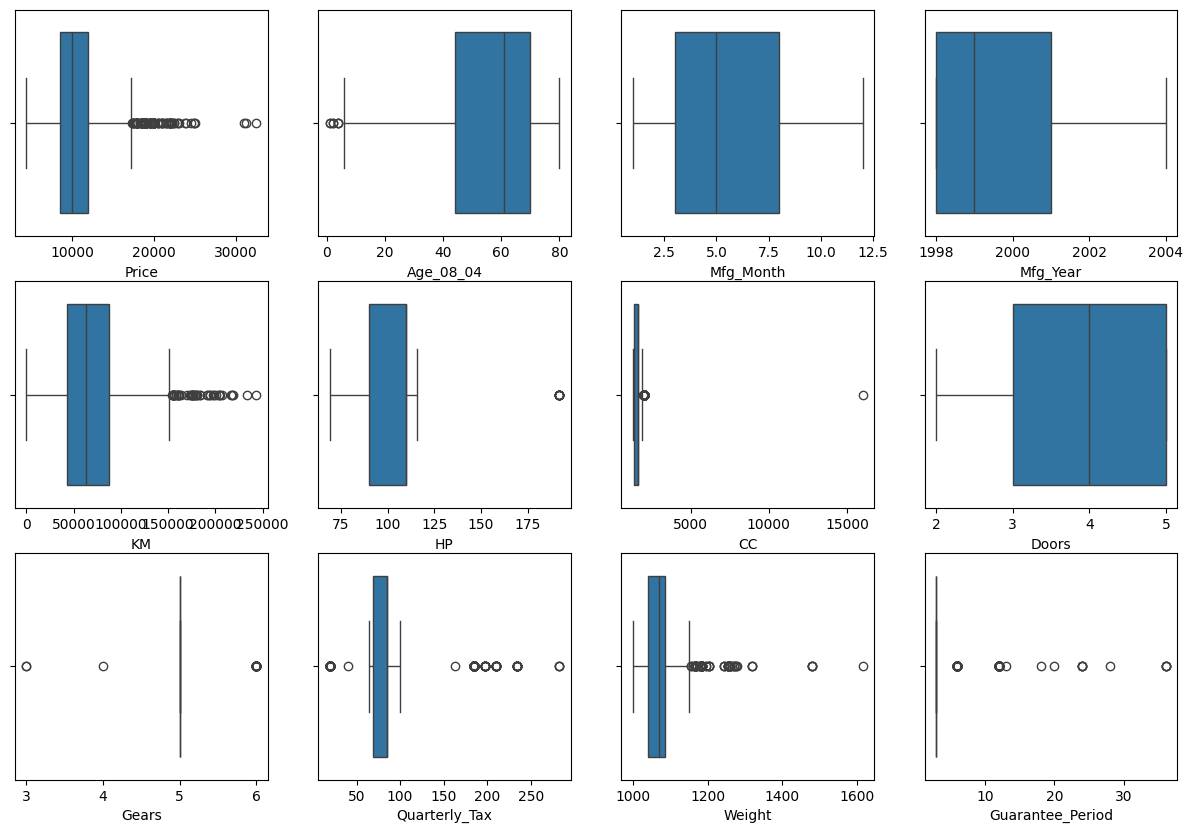

In [32]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, el in enumerate(df_for_corr.columns.array):
    sb.boxplot(data=df_for_corr, x=el, ax=axes[i//4, i%4])

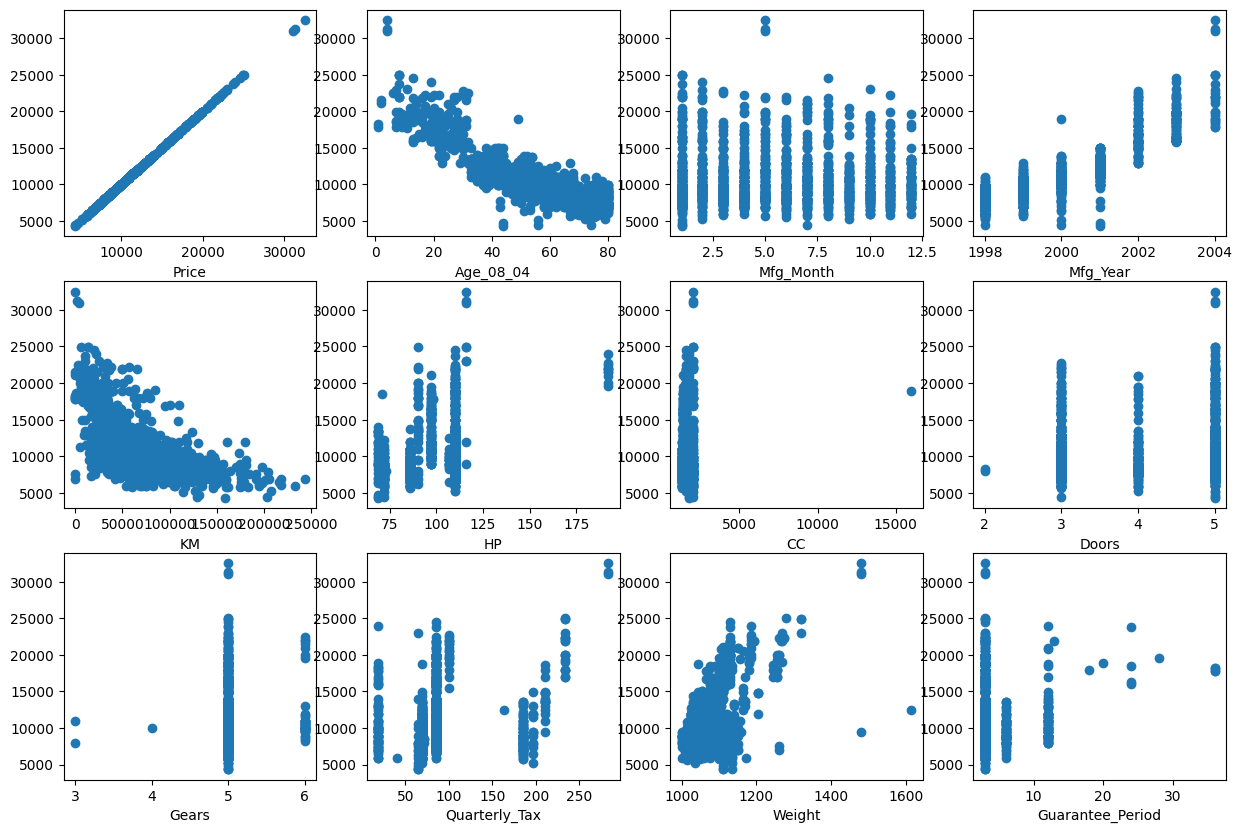

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, el in enumerate(df_for_corr.columns.array):
    axes[i//4, i%4].scatter(x=df_for_corr[el],y=df_for_corr['Price'])
    axes[i//4, i%4].set_xlabel(el)

(array([283., 122., 191.,  31., 301., 278., 220.,   3.,   4.,   3.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

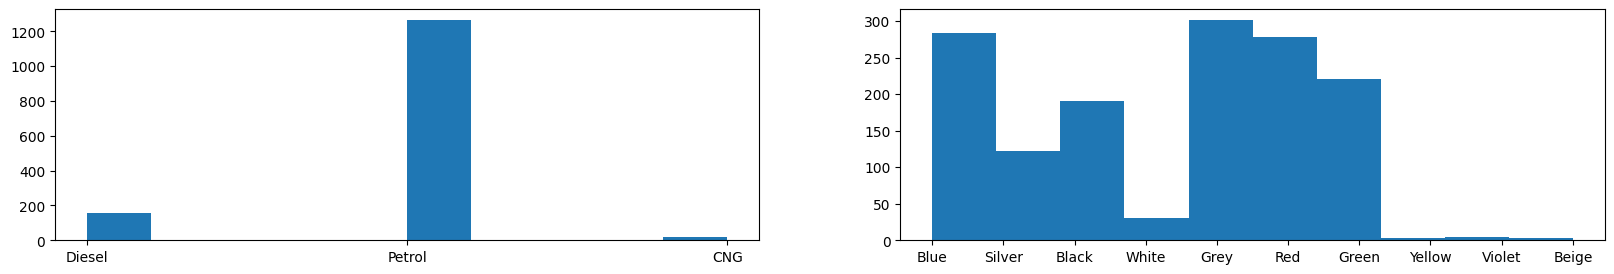

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 3))
axes[0].hist(df['Fuel_Type'])
axes[1].hist(df['Color'])
    

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Color','Fuel_Type'], drop_first=True)

In [ ]:
for el in bins:
    df_encoded[el] = df_encoded[el].astype(bool)

In [ ]:
bins = df_encoded.select_dtypes('bool').columns.tolist()

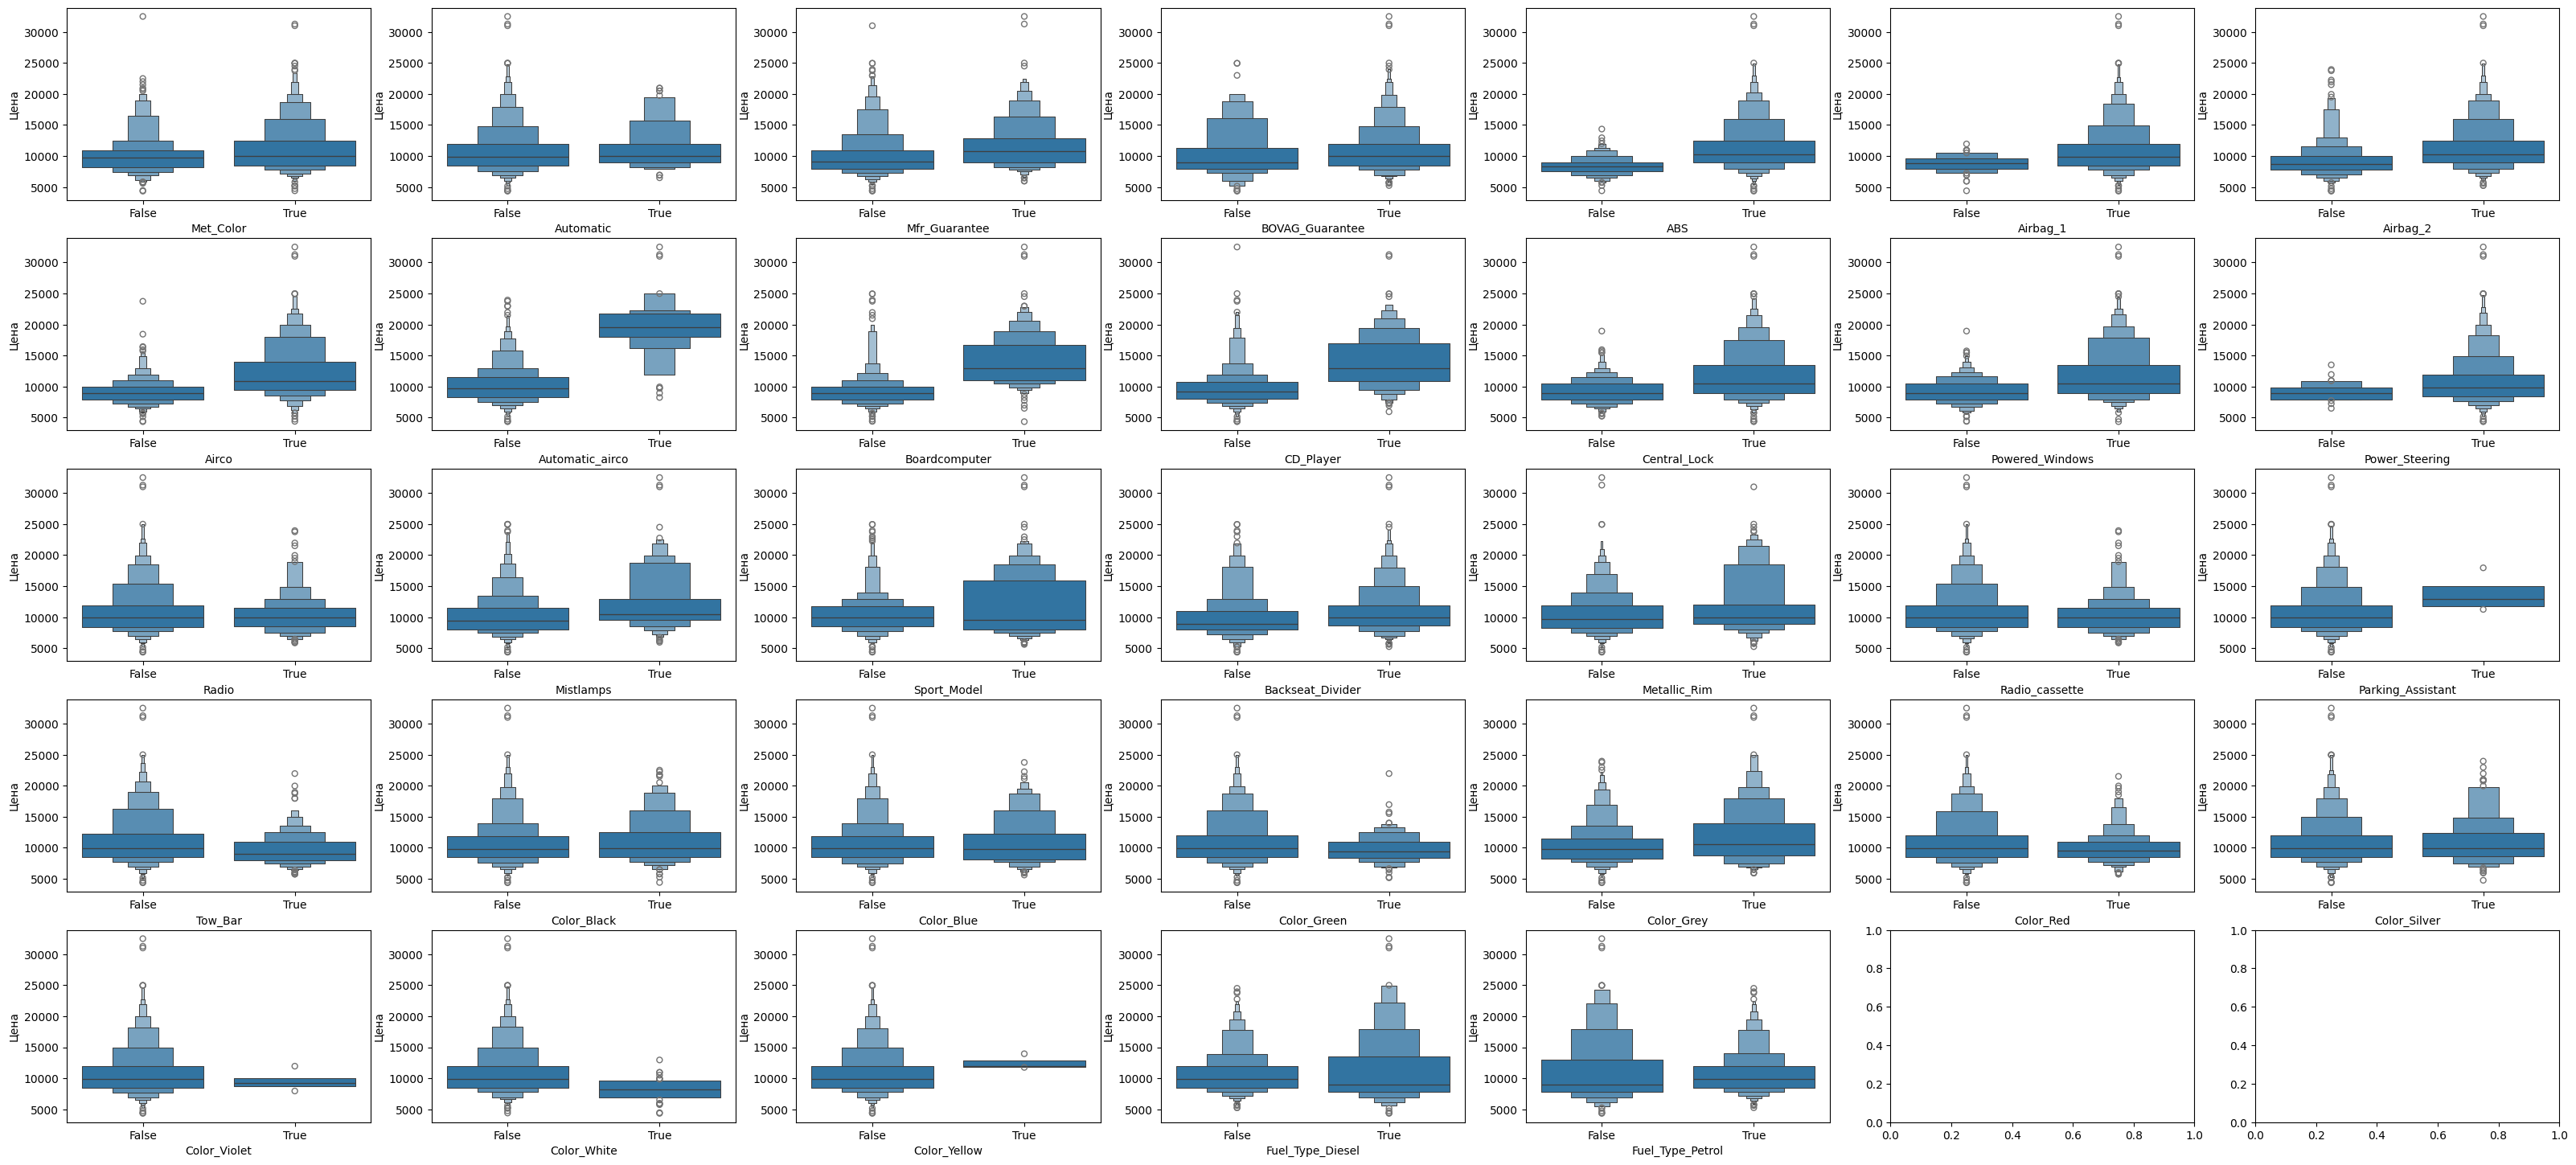

In [ ]:
fig, axes = plt.subplots(5, 7, figsize=(40, 18))

for i, el in enumerate(bins):
    sb.boxenplot(data=df_encoded, x=el,y=df_encoded['Price'], ax=axes[i//7, i%7])
    axes[i//7, i%7].set_xlabel(el)  
    axes[i//7, i%7].set_ylabel('Цена')  

In [ ]:
bins.append('Price')

<Axes: >

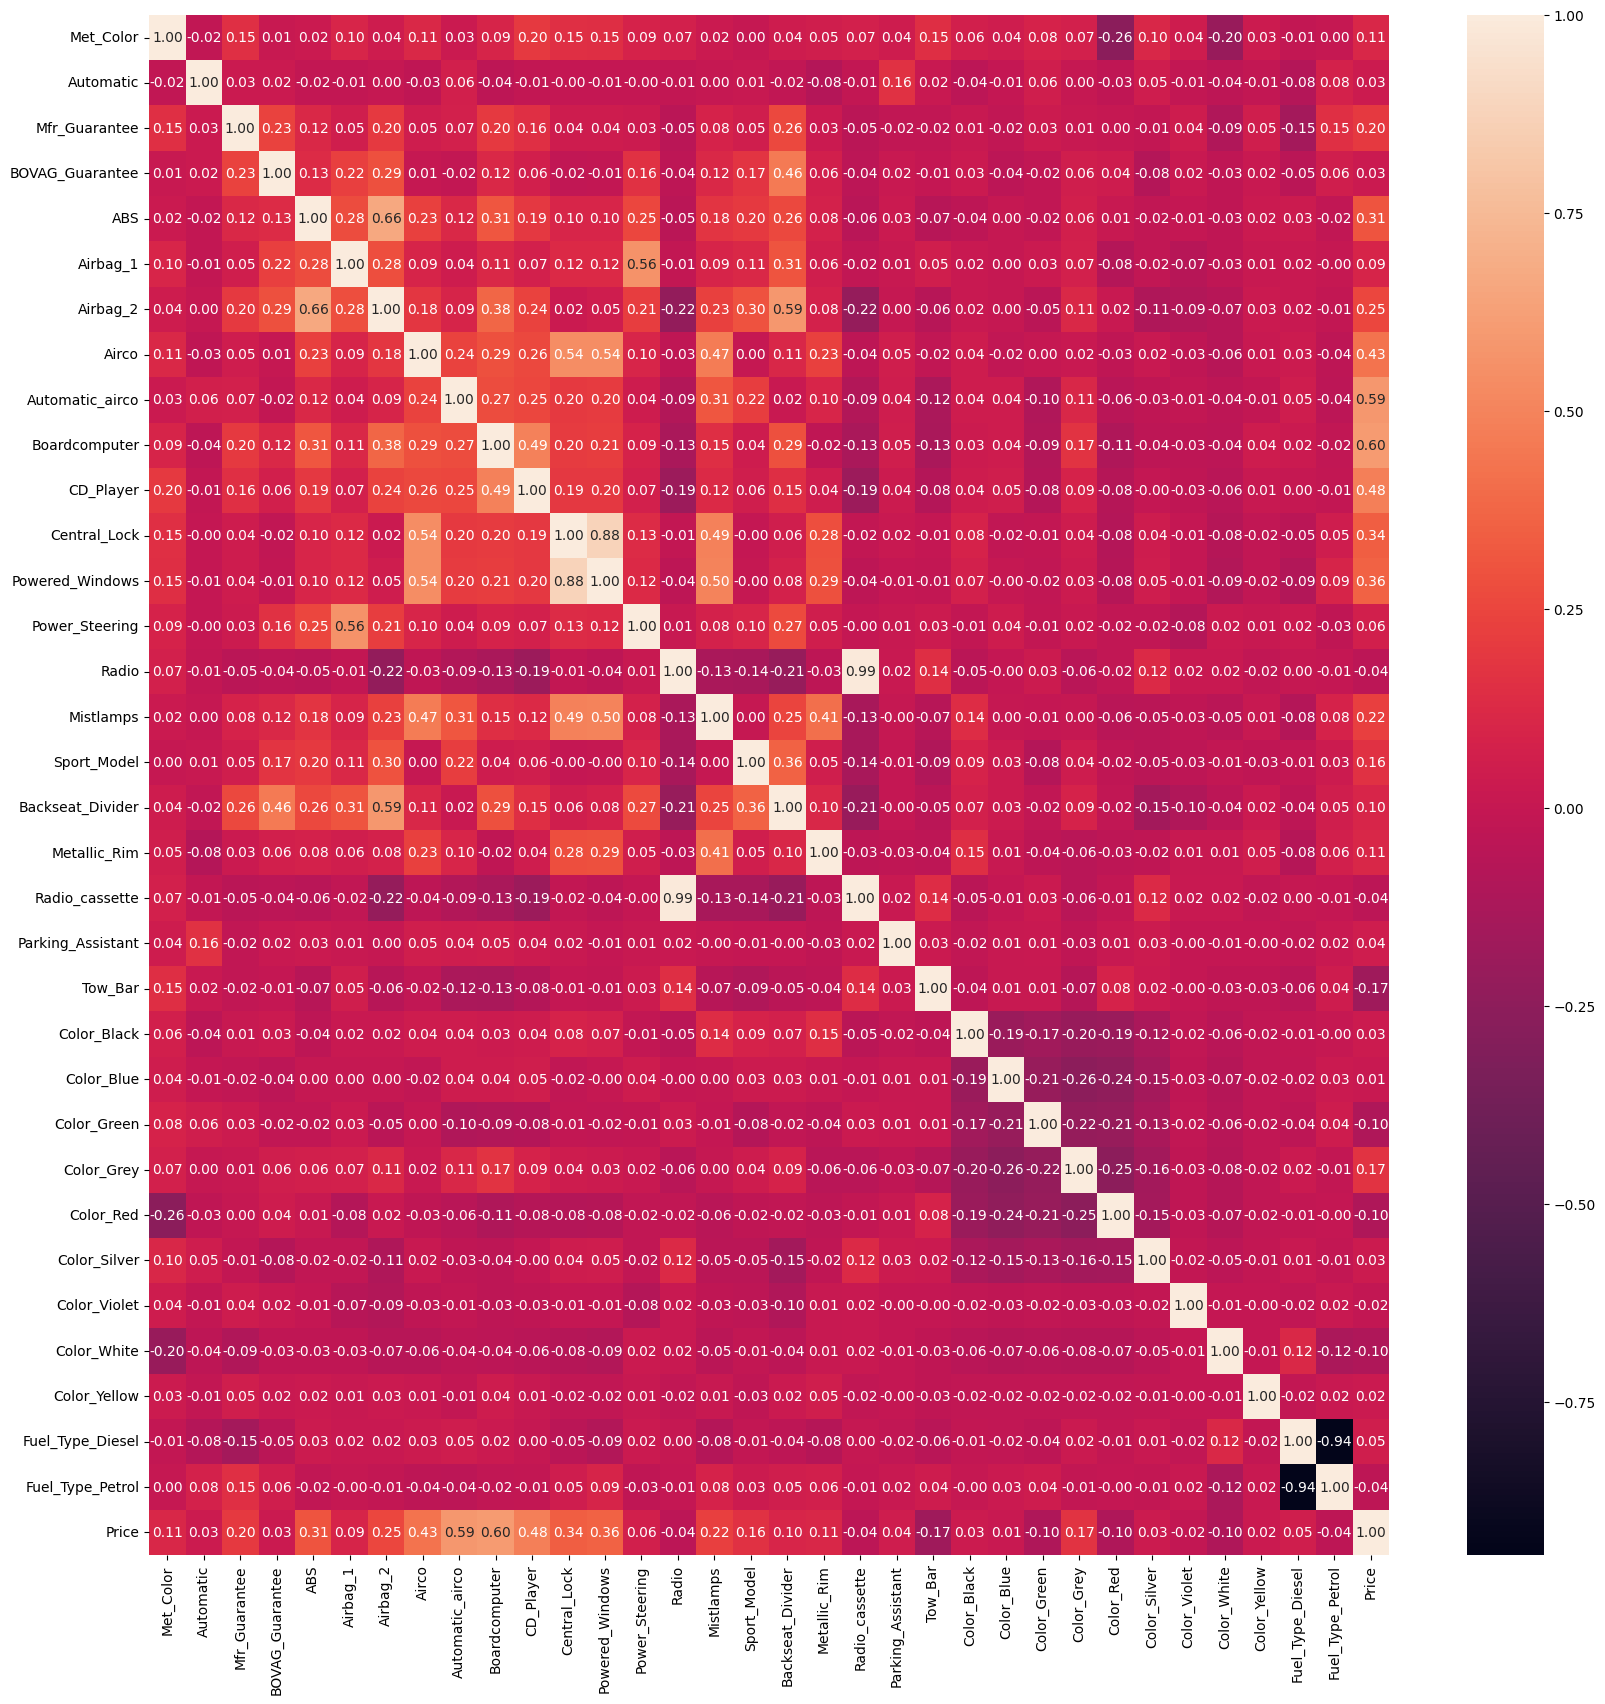

In [ ]:
plt.figure(figsize=(20, 20))
sb.heatmap(df_encoded[bins].corr(),annot=True,fmt=".2f")

In [ ]:
trg = TargetEncoder(smoothing=True)

df_encoded['Model']=trg.fit_transform(df_encoded['Model'], df_encoded['Price'])

In [ ]:
df_encoded.corr().at['Model','Price']

np.float64(0.4869307110274053)

# Что я понял:
нет пропусков, есть выбросы , данные распределены неравномерно. Цена сильно зависит от возраста, пробега, веса. 
# Что я делал
использовал onehot для цвета и вида топлива targetencoding для модели авто. 
Далее также попробую удалить признаки с малой корелляцией (т.к. они могут создавать лишний шум), проверю разные скейлеры, PolynomialFeatures создадут новые фичи.

In [ ]:
y=df_encoded['Price']
X=df_encoded.drop(columns=['Price'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Разделение выборки
с помощью train_test_split; Если мы будем обучать и проверять на одном и том же, то будет переобучение (запоинание правильных ответов)

In [ ]:
pipeline = Pipeline([('scaler', RobustScaler()),('poly', PolynomialFeatures(degree=2)),('regressor', LinearRegression())])

param_grid = {'poly__degree': [1, 2],
    'scaler' : [RobustScaler(), StandardScaler(), MinMaxScaler(), None]}
start = time.time()
grid_search = GridSearchCV(pipeline,  param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

y_pred =grid_search.best_estimator_.predict(X_test)
r2 = r2_score(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mape = mean_absolute_percentage_error(y_test,y_pred)

y_train_pred = grid_search.best_estimator_.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print('Best params: ',grid_search.best_params_)
print('Best score: ',grid_search.best_score_)
print('R2: ', r2)
print('R2(train): ', train_r2)
print('RMSE: ',rmse)
print('MAPE', mape)
print('Time: ',time.time()-start)

Best params:  {'poly__degree': 1, 'scaler': StandardScaler()}
Best score:  -3053136.32599555
R2:  0.893339199934025
R2(train):  0.9152795766299093
RMSE:  1192.9595689630883
MAPE 0.08247295399258839
Time:  13.339206457138062


In [ ]:
pipeline = Pipeline([('scaler', RobustScaler()),('poly', PolynomialFeatures(degree=2)),('regressor', Ridge())])

param_grid = {'poly__degree': [1, 2],
    'scaler' : [RobustScaler(), StandardScaler(), MinMaxScaler(), None],
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10 , 100 , 1000, 10000]}
start = time.time()
grid_search = GridSearchCV(pipeline,  param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

y_pred =grid_search.best_estimator_.predict(X_test)
r2 = r2_score(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mape = mean_absolute_percentage_error(y_test,y_pred)

y_train_pred = grid_search.best_estimator_.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print('Best params: ',grid_search.best_params_)
print('Best score: ',grid_search.best_score_)
print('R2: ', r2)
print('R2(train): ', train_r2)
print('RMSE: ',rmse)
print('MAPE', mape)
print('Time: ',time.time()-start)

Best params:  {'poly__degree': 1, 'regressor__alpha': 100, 'scaler': StandardScaler()}
Best score:  -1419426.6619593184
R2:  0.8938709163572345
R2(train):  0.9100278268646901
RMSE:  1189.9823331549862
MAPE 0.08333550781780079
Time:  16.56562376022339


In [ ]:
pipeline = Pipeline([('scaler', RobustScaler()),('poly', PolynomialFeatures(degree=2)),('regressor', Lasso(max_iter=1000))])

param_grid = {'poly__degree': [1, 2],
    'scaler' : [RobustScaler(), StandardScaler(), MinMaxScaler(), None],
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10 , 100 , 1000, 10000]}
start = time.time()
grid_search = GridSearchCV(pipeline,  param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mape = mean_absolute_percentage_error(y_test,y_pred)

y_train_pred = grid_search.best_estimator_.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print('Best params: ',grid_search.best_params_)
print('Best score: ',grid_search.best_score_)
print('R2: ', r2)
print('R2(train): ', train_r2)
print('RMSE: ',rmse)
print('MAPE', mape)
print('Time: ',time.time()-start)

Best params:  {'poly__degree': 2, 'regressor__alpha': 100, 'scaler': StandardScaler()}
Best score:  -1200024.5823421904
R2:  0.8938709163572345
R2(train):  0.9243536520885488
RMSE:  1189.9823331549862
MAPE 0.08333550781780079
Time:  49.60121417045593


In [ ]:
result = []
for t in [0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
    all = df_encoded.corr()['Price'].abs()
    trash = all[all <= t].index
    trash = trash.to_list()
   
    X_clear = X.drop(columns=trash)
    X_train, X_test, y_train, y_test = train_test_split(X_clear, y, test_size=0.2, random_state=42)

    pipeline = Pipeline([('scaler', RobustScaler()),('poly', PolynomialFeatures(degree=2)),('regressor', LinearRegression())])

    param_grid = {'poly__degree': [1, 2],
        'scaler' : [RobustScaler(), StandardScaler(), MinMaxScaler(), None]}
    start = time.time()
    grid_search = GridSearchCV(pipeline,  param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

    grid_search.fit(X_train, y_train)

    y_pred =grid_search.best_estimator_.predict(X_test)
    r2 = r2_score(y_test,y_pred)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mape = mean_absolute_percentage_error(y_test,y_pred)

    y_train_pred = grid_search.best_estimator_.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)
    result.append({'Model' : 'LinearRegression',**grid_search.best_params_,'Best score' :grid_search.best_score_,
                   'R2': r2, 'R2(train)': train_r2,'RMSE':rmse,'MAPE':mape, 'Time':time.time()-start, 'trashhold':t})



    pipeline = Pipeline([('scaler', RobustScaler()),('poly', PolynomialFeatures(degree=2)),('regressor', Ridge())])

    param_grid = {'poly__degree': [1, 2],
        'scaler' : [RobustScaler(), StandardScaler(), MinMaxScaler(), None],
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10 , 100 , 1000, 10000]}
    start = time.time()
    grid_search = GridSearchCV(pipeline,  param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

    grid_search.fit(X_train, y_train)

    y_pred =grid_search.best_estimator_.predict(X_test)
    r2 = r2_score(y_test,y_pred)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mape = mean_absolute_percentage_error(y_test,y_pred)

    y_train_pred = grid_search.best_estimator_.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)

    result.append({'Model' : 'Ridge',**grid_search.best_params_,'Best score' :grid_search.best_score_,
                   'R2': r2, 'R2(train)': train_r2,'RMSE':rmse,'MAPE':mape, 'Time':time.time()-start, 'trashhold':t})


    pipeline = Pipeline([('scaler', RobustScaler()),('poly', PolynomialFeatures(degree=2)),('regressor', Lasso(max_iter=1000))])

    param_grid = {'poly__degree': [1, 2],
        'scaler' : [RobustScaler(), StandardScaler(), MinMaxScaler(), None],
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10 , 100 , 1000, 10000]}
    start = time.time()
    grid_search = GridSearchCV(pipeline,  param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

    grid_search.fit(X_train, y_train)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mape = mean_absolute_percentage_error(y_test,y_pred)

    y_train_pred = grid_search.best_estimator_.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)

    result.append({'Model' : 'Lasso',**grid_search.best_params_,'Best score' :grid_search.best_score_,
                   'R2': r2, 'R2(train)': train_r2,'RMSE':rmse,'MAPE':mape, 'Time':time.time()-start, 'trashhold':t})

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'d2_log_loss_score', 'neg_max_error', 'neg_root_mean_squared_log_error', 'recall', 'matthews_corrcoef', 'f1_macro', 'rand_score', 'neg_brier_score', 'neg_mean_squared_error', 'roc_auc_ovo', 'v_measure_score', 'normalized_mutual_info_score', 'f1_micro', 'accuracy', 'jaccard', 'd2_brier_score', 'f1_weighted', 'mutual_info_score', 'neg_negative_likelihood_ratio', 'completeness_score', 'positive_likelihood_ratio', 'roc_auc_ovo_weighted', 'roc_auc_ovr', 'd2_absolute_error_score', 'jaccard_macro', 'adjusted_mutual_info_score', 'jaccard_samples', 'neg_root_mean_squared_error', 'fowlkes_mallows_score', 'precision_weighted', 'recall_weighted', 'average_precision', 'jaccard_micro', 'precision_macro', 'neg_mean_poisson_deviance', 'homogeneity_score', 'roc_auc', 'f1', 'r2', 'f1_samples', 'jaccard_weighted', 'explained_variance', 'neg_mean_squared_log_error', 'neg_mean_gamma_deviance', 'precision_samples', 'adjusted

In [34]:
results = pd.DataFrame(result)
top = results.sort_values("Best score", ascending=False).head(10)
top

,Model,poly__degree,scaler,Best score,R2,R2(train),RMSE,MAPE,Time,trashhold,regressor__alpha
11,Lasso,2,None,-1.117637e+06,0.912693,0.925422,1079.311127,0.080001,5.273395,0.20,10000.0
10,Ridge,2,RobustScaler(),-1.138439e+06,0.912693,0.937456,1079.311127,0.080001,1.449146,0.20,10.0
14,Lasso,2,None,-1.160099e+06,0.929382,0.920969,970.691673,0.079135,3.267218,0.30,10000.0
8,Lasso,2,StandardScaler(),-1.183030e+06,0.902880,0.921139,1138.355657,0.082839,22.501337,0.10,100.0
2,Lasso,2,StandardScaler(),-1.200025e+06,0.893871,0.924354,1189.982333,0.083336,45.085576,0.00,100.0
13,Ridge,2,RobustScaler(),-1.206409e+06,0.929382,0.928162,970.691673,0.079135,1.210411,0.30,10.0
5,Lasso,2,StandardScaler(),-1.207335e+06,0.892385,0.921657,1198.282815,0.085612,25.714731,0.05,100.0
17,Lasso,2,None,-1.281320e+06,0.902942,0.913017,1137.989925,0.082642,1.722607,0.40,100.0
16,Ridge,2,MinMaxScaler(),-1.283227e+06,0.902942,0.911934,1137.989925,0.082642,1.015122,0.40,1.0
19,Ridge,2,RobustScaler(),-1.318573e+06,0.905880,0.906594,1120.636189,0.086369,0.932506,0.50,10.0


# Как проходило обучение
Обучение проходило хорошо. по mse.Сначало c перебором по гиперпараметрам (линейная - poly и scaler; ridge, lasso - также alpha). Потом попробывали удалить слабые признаки (лучший получился с удаленем при корелляции < 0.2;)
# Сравнение скорости:
самая быстрая - линейная т.к. это минимум вычислений для градиунтного спуска (в lasso и ridge добавляется слагаемое);
ridge - чуть медленнее, но и score лучше в 2 раза; 
lasso самое медленное, но и лучший score, иногда даже не может дойти до цели рпи градиентном спуске (возможно из-за отсутствия scaler)